# Practical Session 7: Logistic Regression and Probabilistic Classification

This notebook follows the current practical script and is written as a teaching
solution. It compares a library model, an optimization-based model, and gradient
descent from scratch on a small medical-style data set.


In [1]:
# Import NumPy for numerical vector and matrix operations.
import numpy as np
# Import pandas for compact result tables.
import pandas as pd
# Import Matplotlib for the loss curve and decision-boundary plots.
import matplotlib.pyplot as plt
# Import SciPy's optimizer for the direct cross-entropy minimization.
from scipy.optimize import minimize
# Import scikit-learn's logistic regression as the reference implementation.
from sklearn.linear_model import LogisticRegression
# Import an accuracy metric for quick evaluation.
from sklearn.metrics import accuracy_score

# Format arrays compactly for notebook output.
np.set_printoptions(precision=4, suppress=True)

# Fix the seed for reproducibility, even though this notebook uses deterministic data.
rng = np.random.default_rng(2024)

# Create the two-feature training data set: age and blood pressure.
X = np.array(
    [
        [42, 118],
        [50, 130],
        [61, 142],
        [65, 155],
        [72, 168],
        [47, 125],
        [55, 145],
        [68, 162],
        [75, 176],
        [58, 150],
        [63, 158],
        [45, 120],
    ],
    dtype=float,
)
# Store the binary labels in {0, 1} form.
y = np.array([0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0], dtype=int)

# Standardize the features to improve numerical optimization behavior.
feature_mean = X.mean(axis=0)
feature_std = X.std(axis=0, ddof=0)
X_scaled = (X - feature_mean) / feature_std


def sigmoid(z):
    # Map linear scores to probabilities in the interval (0, 1).
    # TODO: Implement the logistic sigmoid function.
    return ...


def unpack(theta):
    # Split the joint parameter vector into weights and scalar bias.
    return theta[:-1], theta[-1]


def logistic_loss(theta, X, y, lam=0.0):
    # Recover weights and bias from the flat parameter vector.
    w, b = unpack(theta)
    # Compute the linear scores of all samples.
    logits = X @ w + b
    probabilities = sigmoid(logits)
    # Add a small epsilon to keep the logarithms numerically safe.
    eps = 1e-12
    # TODO: Compute the empirical cross-entropy term.
    cross_entropy = ...
    # Add the optional L2 regularization term.
    return cross_entropy + lam * np.dot(w, w)


def logistic_gradient(theta, X, y, lam=0.0):
    # Recover weights and bias for the gradient computation.
    w, b = unpack(theta)
    # Compute model probabilities for all samples.
    probabilities = sigmoid(X @ w + b)
    error = probabilities - y
    # Differentiate the loss with respect to weights and bias.
    grad_w = X.T @ error + 2 * lam * w
    grad_b = np.sum(error)
    return np.r_[grad_w, grad_b]


## Task 1: Reference implementation with scikit-learn

We first train a library model and use it as a numerical reference for the custom
implementations that follow.


In [2]:
# Set C very large so the reference model behaves like an almost unregularized fit.
sklearn_model = LogisticRegression(C=1e6, solver="lbfgs", max_iter=5000)

# Fit the logistic model on the standardized features.
# TODO: Fit the scikit-learn logistic-regression model.
...
# Compute class-1 probabilities on the training set.
sklearn_probabilities = sklearn_model.predict_proba(X_scaled)[:, 1]
# Convert probabilities to hard labels using the default threshold 0.5.
sklearn_predictions = sklearn_model.predict(X_scaled)

print("Reference coefficients:", sklearn_model.coef_)
print("Reference intercept:", sklearn_model.intercept_)
print("Reference training accuracy:", accuracy_score(y, sklearn_predictions))


Reference coefficients: [[ 5.5018 -1.222 ]]
Reference intercept: [1.1462]
Reference training accuracy: 0.8333333333333334


## Task 2: Optimization-based logistic regression with SciPy

We now minimize the empirical cross-entropy loss directly with `scipy.optimize`.


In [3]:
# Start the optimizer from the zero vector.
theta0 = np.zeros(X_scaled.shape[1] + 1)
# TODO: Minimize the custom logistic loss with SciPy.
scipy_result = ...
# Extract the fitted weights and bias.
theta_scipy = scipy_result.x
w_scipy, b_scipy = unpack(theta_scipy)
# Compute probabilities and classes for evaluation.
probabilities_scipy = sigmoid(X_scaled @ w_scipy + b_scipy)
predictions_scipy = (probabilities_scipy >= 0.5).astype(int)

print("Optimizer success:", scipy_result.success)
print("SciPy parameters:", theta_scipy)
print("Difference to scikit-learn weights:", w_scipy - sklearn_model.coef_.ravel())
print("Difference to scikit-learn intercept:", b_scipy - sklearn_model.intercept_[0])


Optimizer success: True
SciPy parameters: [ 5.5017 -1.2217  1.1462]
Difference to scikit-learn weights: [-0.0002  0.0004]
Difference to scikit-learn intercept: 5.6154010641407126e-05


## Task 3: Batch gradient descent from scratch

The next cell implements the full training loop manually and records the loss after
every iteration.


Gradient descent iterations: 4000
Gradient descent accuracy: 0.8333333333333334


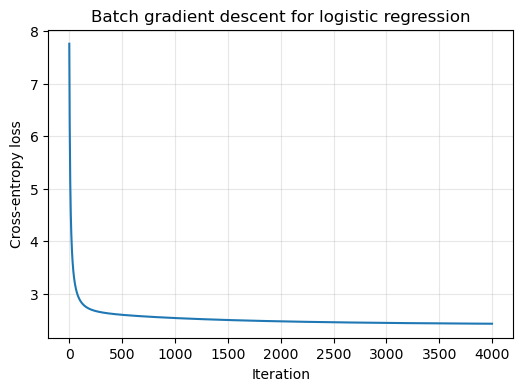

In [4]:
# Initialize the gradient-descent parameters at zero.
theta_gd = np.zeros(X_scaled.shape[1] + 1)
# Choose a fixed learning rate for the batch updates.
learning_rate = 0.15
# Set a generous iteration budget so convergence can be observed clearly.
max_iterations = 4000
# Track the loss values for the learning-curve plot.
loss_history = []

for iteration in range(max_iterations):
    # Compute the current gradient of the unregularized cross-entropy loss.
    grad = logistic_gradient(theta_gd, X_scaled, y, lam=0.0)
    # Scale the gradient by the sample size to keep the step size interpretable.
    # TODO: Perform one batch-gradient-descent update step.
    ...
    # Record the updated loss value after the parameter step.
    loss_history.append(logistic_loss(theta_gd, X_scaled, y, lam=0.0))
    # Stop when the gradient norm becomes very small.
    if np.linalg.norm(grad) < 1e-6:
        break

# Recover weights and bias from the final iterate.
w_gd, b_gd = unpack(theta_gd)
probabilities_gd = sigmoid(X_scaled @ w_gd + b_gd)
predictions_gd = (probabilities_gd >= 0.5).astype(int)

print("Gradient descent iterations:", len(loss_history))
print("Gradient descent accuracy:", accuracy_score(y, predictions_gd))

# Plot the decrease of the cross-entropy loss over time.
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Cross-entropy loss")
plt.title("Batch gradient descent for logistic regression")
plt.grid(True, alpha=0.3)
plt.show()


## Task 4: Probability prediction for a new sample

We evaluate all trained models on the patient with age `70` and blood pressure `160`.


In [5]:
# Store the new patient sample in raw feature coordinates.
x_new_raw = np.array([[70.0, 160.0]])
# Apply the same standardization used during training.
x_new_scaled = (x_new_raw - feature_mean) / feature_std

# Compute the class-1 probability under each model.
prob_reference = sklearn_model.predict_proba(x_new_scaled)[:, 1][0]
prob_scipy = sigmoid(x_new_scaled @ w_scipy + b_scipy)[0]
prob_gd = sigmoid(x_new_scaled @ w_gd + b_gd)[0]

# Summarize probability and hard-class predictions in one table.
prediction_summary = pd.DataFrame(
    [
        {
            "model": "scikit-learn",
            "probability_class_1": prob_reference,
            "predicted_class": int(prob_reference >= 0.5),
        },
        {
            "model": "SciPy optimizer",
            "probability_class_1": prob_scipy,
            "predicted_class": int(prob_scipy >= 0.5),
        },
        {
            "model": "gradient descent",
            "probability_class_1": prob_gd,
            "predicted_class": int(prob_gd >= 0.5),
        },
    ]
)
display(prediction_summary)


,model,probability_class_1,predicted_class
0,scikit-learn,0.998269,1
1,SciPy optimizer,0.998270,1
2,gradient descent,0.996774,1


## Task 5: Decision boundary and confidence visualization

Because the data has two features, we can visualize the probability surface and the
decision boundary directly in the original feature plane.


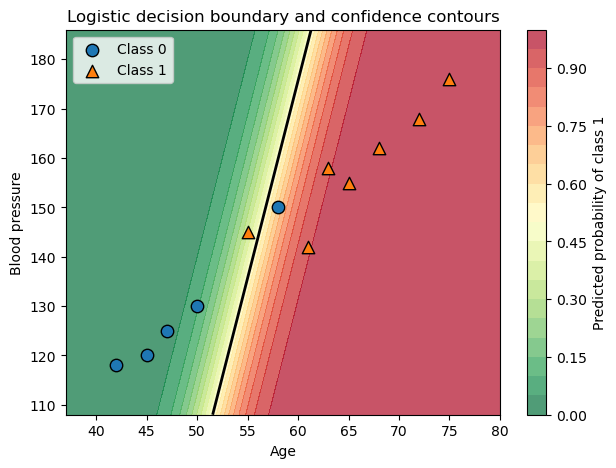

In [6]:
# Build a fine grid over the visible feature range.
age_grid = np.linspace(X[:, 0].min() - 5, X[:, 0].max() + 5, 200)
bp_grid = np.linspace(X[:, 1].min() - 10, X[:, 1].max() + 10, 200)
age_mesh, bp_mesh = np.meshgrid(age_grid, bp_grid)
grid_raw = np.column_stack([age_mesh.ravel(), bp_mesh.ravel()])
# Standardize the grid with the training statistics before prediction.
grid_scaled = (grid_raw - feature_mean) / feature_std
grid_prob = sklearn_model.predict_proba(grid_scaled)[:, 1].reshape(age_mesh.shape)

# Plot filled probability contours and overlay the 0.5 decision boundary.
plt.figure(figsize=(7, 5))
contour = plt.contourf(age_mesh, bp_mesh, grid_prob, levels=20, cmap="RdYlGn_r", alpha=0.7)
plt.colorbar(contour, label="Predicted probability of class 1")
plt.contour(age_mesh, bp_mesh, grid_prob, levels=[0.5], colors="black", linewidths=2)
# Plot the original data points on top of the contour map.
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Class 0", s=80, edgecolor="black")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Class 1", s=80, marker="^", edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Blood pressure")
plt.title("Logistic decision boundary and confidence contours")
plt.legend()
plt.show()


## Task 6: Regularization study

We solve the regularized loss for several values of `lambda` and monitor the weight
norm, training accuracy, and prediction for the new patient.


,lambda,weight_norm,training_accuracy,"probability_for_(70,160)"
0,0.000100,5.582987,0.833333,0.998219
1,0.000285,5.491345,0.833333,0.998127
2,0.000811,5.263562,0.833333,0.997877
3,0.002310,4.788622,0.833333,0.997228
4,0.006579,4.042070,0.833333,0.995659
5,0.018738,3.205191,0.833333,0.992035
6,0.053367,2.496556,0.833333,0.983597
7,0.151991,1.924655,0.916667,0.964065
8,0.432876,1.409906,0.916667,0.922456
9,1.232847,0.939962,0.916667,0.848934


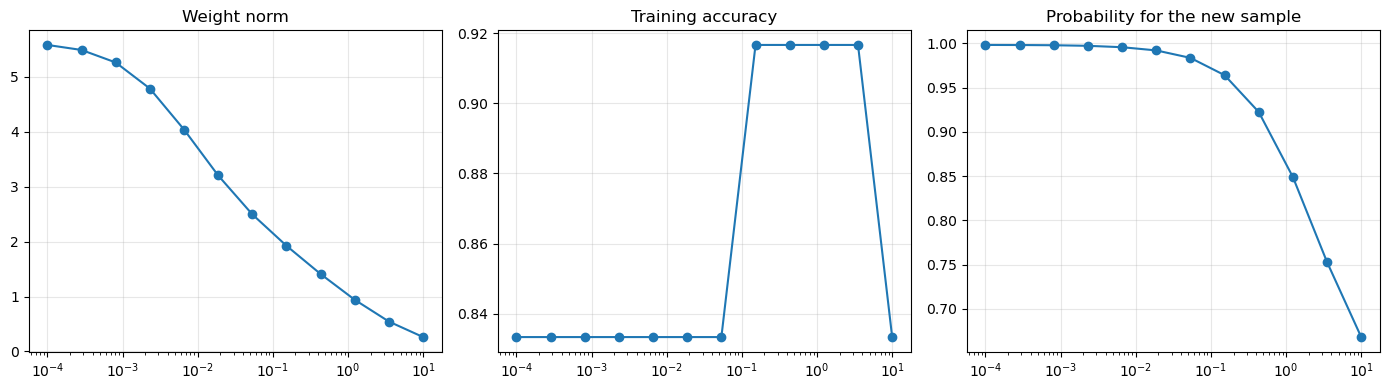

In [7]:
# Use a logarithmic lambda grid to cover weak and strong regularization.
lambda_grid = np.logspace(-4, 1, 12)
regularization_rows = []

for lam in lambda_grid:
    # Solve the regularized optimization problem for the current lambda value.
    result = minimize(
        logistic_loss,
        theta0,
        args=(X_scaled, y, lam),
        jac=logistic_gradient,
        method="L-BFGS-B",
    )
    theta_reg = result.x
    w_reg, b_reg = unpack(theta_reg)
    # Evaluate the fitted model on the training data and on the new sample.
    probs_reg = sigmoid(X_scaled @ w_reg + b_reg)
    preds_reg = (probs_reg >= 0.5).astype(int)
    prob_new = sigmoid(x_new_scaled @ w_reg + b_reg)[0]
    regularization_rows.append(
        {
            "lambda": lam,
            "weight_norm": np.linalg.norm(w_reg),
            "training_accuracy": accuracy_score(y, preds_reg),
            "probability_for_(70,160)": prob_new,
        }
    )

# Convert the sweep results into a DataFrame.
regularization_df = pd.DataFrame(regularization_rows)
display(regularization_df)

# Plot all monitored quantities as functions of lambda.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].semilogx(regularization_df["lambda"], regularization_df["weight_norm"], marker="o")
axes[0].set_title("Weight norm")
axes[0].grid(True, alpha=0.3)

axes[1].semilogx(regularization_df["lambda"], regularization_df["training_accuracy"], marker="o")
axes[1].set_title("Training accuracy")
axes[1].grid(True, alpha=0.3)

axes[2].semilogx(
    regularization_df["lambda"],
    regularization_df["probability_for_(70,160)"],
    marker="o",
)
axes[2].set_title("Probability for the new sample")
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
